In [ ]:
import sisl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from ase.visualize import view
from tqdm.notebook import tqdm
from pathlib import Path

import ipywidgets
from ipywidgets import interact
from fractions import Fraction


import utils
print(f"utils : {utils.__version__}")
from utils.structure import find_nearest_atoms, infer_centersize
from utils.energies import hamiltonian, multi_LDOS
from utils.loader import load_datastructure, path_finder
from utils import pretty_print_columns
from utils._wrappers import timeit


from sisl.viz.processors.math import normalize


from utils.plots import plot_with_center, mark_electrode # plotting


# %reload_ext line_profiler



# Global parameters

In [ ]:
ENERGIES = np.linspace(-2, 2, num=100)

# Benchmark full device: flake convergence
This is how I expect the final structure to converge when computing the LDOS from self-energies. Calculated using [flake_size_conv.py](../../QTM/flake_size_conv.py)

<img src="../../QTM/figures/flake_size_conv.svg">

# Convergence for device: Reduced structure (3 arms)

In [ ]:
l = 2
i = 6
LWC = infer_centersize(l, i)
electrode, ribbon, device, DATA = load_datastructure(LWC=LWC)
energies, ldos, lr_idx = DATA["energies"], DATA["ldos"], DATA["lr_idx"]

Nk, NE, Na = ldos.shape # number of k-points, energy values, and atoms for device
atoms_style = mark_electrode(lr_idx)

plot_with_center(device, atoms_style=atoms_style)

## Plotting LDOS for a range of modulation paramters

In [ ]:
def interactive_params(device, Nk):
    # Determine k-point options
    DEVICE_CENTER_ATOMS = find_nearest_atoms(device.xyz, device.center(), neighbours=6)
    kpts = sisl.MonkhorstPack(hamiltonian(device), [Nk, 1, 1])
    options = [(f"{[str(Fraction(val).limit_denominator(len(kpts)*2)) for val in kvec]})", i) for i, kvec in enumerate(kpts)]
    ks = ipywidgets.Dropdown(options=options, description="k")
    
    # Determine site (only the centermost)
    sites = ipywidgets.Dropdown(options=DEVICE_CENTER_ATOMS, description="Site")
    
    # Option for using normalized data
    norm = ipywidgets.Checkbox(value=False, description="Normalize", indent=True)
    # same = ipywidgets.Checkbox(value=True, description="Plot in same figure", indent=True)
    return ks, sites, norm


In [ ]:
def plot_ldos(kidx, s, norm=True):
    """Plot LDOS from self-energy calculation."""
    vmin = ldos[kidx, :, sites.options].mean()
    
    X1 = ldos[kidx, :, s]
    
    fig, axes = plt.subplots(1,1)
    if norm: # plot in the save figure
        X1 = normalize(X1, vmin=vmin, vmax = 1)
        axes.set_xlabel("LDOS (normalized)")
    else:
        axes.set_xlabel(f"LDOS")
    
    axes.plot(X1, energies, label="SE (LDOS)")
    axes.set_ylabel("E")
    axes.axvline(0, color="k", linestyle="--")
    
    fig.suptitle("L={:}, W={:}, C={:}".format(*LWC))

ks, sites, norm = interactive_params(device, Nk=Nk)
interact(plot_ldos, kidx=ks, s=sites, norm=norm)

## Plot LDOS pr. energy (interactive)

In [ ]:
def scale_by_ldos(ldos, Eidx, atoms_style = None):
    scaling = lambda E: 10*E + 0.02
    Nk, NE, Ns = ldos.shape
    C_ATOMS = find_nearest_atoms(device.xyz, device.center(), neighbours=6)
    vmin = ldos[..., C_ATOMS].mean()
    
    
    norm_ldos = normalize(ldos, vmin=vmin, vmax=1)
    style = {"atoms": range(Ns),
             "size": 1.1*scaling(norm_ldos[0, Eidx, :])}
    if atoms_style is None:
        atoms_style = []
    
    atoms_style.append(style)
    return atoms_style
    
style = scale_by_ldos(ldos, 0, atoms_style)

In [ ]:
_atoms_style = mark_electrode(lr_idx)

def proj_ldos(Eidx):
    _style = scale_by_ldos(ldos, Eidx, _atoms_style)
    fig = device.plot(axes="xy", atoms_style=_style, backend="matplotlib", show_cell=False)
        
        
    fig.suptitle(f"(L, W, C) = {LWC}, E = {ENERGIES[Eidx]:.3f}")
    # fig.show()
    # return fig

# idxs = ipywidgets.Dropdown(options=range(ENERGIES.shape[0]), description="E")
idxs = ipywidgets.IntSlider(min=0, max=len(ENERGIES)-1, description="E")
interact(proj_ldos, Eidx=idxs); 

# Note to self:
* Adjust SE-calc: $\Sigma = i\mathrm{LDOS}(E=0)c$, in Hamiltonian for the LDOS calculation find $c$
    * Try different cancstants.
    * Goal: reduced edge states when plotting PDOS (using LDOS) around E=0
* Plot LDOS (as currently) together with electrode DOS to verify behavior. Try for different widths
* Plot BG Vs. electrode width to find correlation (hopefully converging). 
    * BG is in this case equal to "flat-region" around E=0 in the LDOS plot
* Make new routine for computing LDOS for only center atoms (don't solve for all sites if used for plotting LDOS in center region).
    * Make identical routine, but only solving for atom index for the center region.


**Update:**  
See [electrode_dos](notebooks/electrode_DOS.ipynb) for attempt at combining built-in DOS in *y* and self-energy in *x*


## Plotting LDOS for increasing structure size

In [ ]:

def subplot_shape(nplots):
    """Return (nrows, ncols) for nplots with max 4 per figure."""
    if nplots <= 1:
        return (1, 1)
    elif nplots <= 2:
        return (2, 1)   # stacked
    elif nplots <= 4:
        return (2, 2)   # full 2x2 grid
    else:
        raise ValueError("subplot_shape() expects nplots ≤ 4")
    

def parse_lwc(folder):
    return tuple(int(part[1:]) for part in folder.name.split("_"))
def plot_structures(folders, cmap: callable, norm=False, per_fig=4):

    if not isinstance(folders, list):
        folders = [folders]
    handles = []
    labels = []
    N = len(folders)
    num_figs = np.ceil(N/per_fig)
    nrows, ncols = subplot_shape(num_figs)
    
    fig, axes = plt.subplots(nrows, ncols, sharex=True, sharey=True, figsize=(8, 8), dpi=100)
    axes = np.asarray(axes).reshape(nrows, ncols)
    for i, folder in enumerate(folders):
        row = (i // per_fig) // ncols
        col = (i // per_fig) % ncols
        # print(f"{i = }")
        # print(f"{(row, col) = }")
        LWC = parse_lwc(folder)
        *_, device, DATA = load_datastructure(LWC)
        site = find_nearest_atoms(device.xyz, device.center(), neighbours=1)
        X1 = DATA["ldos"][0, :, site]
        if norm:
            X1 = normalize(X1)
        line = axes[row, col].plot(X1, DATA["energies"], label=f"{LWC}", color=cmap(i))
        if isinstance(line, list):
            line = line[0]
        
        handles.append(line)
        labels.append(f"{LWC}")
        bgmin, bgmax, bg = get_bg(LWC)
        axes[row,col].axhline(bgmin, linestyle="--", color="k")
        axes[row, col].axhline(bgmax, linestyle="--", color="k")
        
    
    for ax in axes.flatten():
        ax.axvline(0, linestyle="--", color="k")
        ax.set_xlabel("LDOS", size=16)
        ax.set_ylabel("Energies [eV]", size=16)
    fig.legend(
        handles,
        labels,
        title="(L, W, C)",
        loc="center right",
        bbox_to_anchor=(1.21, 0.5),
        fontsize=14,
        title_fontsize=16,
    )
    plt.tight_layout()

results_folder = path_finder("QTM") / "results"
structure_folders = sorted(results_folder.glob("L*_W*_C*"), 
                           key=lambda p: int(p.name.split("_")[1][1:])
)
N = len(structure_folders)
pltcmap = plt.get_cmap("tab20", N)
TABLEAU = [
"#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F",
"#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC"
]
HIGH_CONTRAST_16 = [
    # Tol Vibrant (7)
    "#0077BB", "#EE7733", "#33BBEE", "#EE3377",
    "#CC3311", "#009988", "#BBBBBB",

    # Tol Muted (9) — also high-contrast and color-blind safe
    "#332288", "#88CCEE", "#44AA99", "#117733",
    "#999933", "#DDCC77", "#661100", "#CC6677",
    "#AA4466",
]
cmap = lambda i: HIGH_CONTRAST_16[i]
plot_structures(structure_folders[0:4], cmap=cmap, norm=True)

In [ ]:
diff = device.xyz[:, :, None] - device.xyz[:, None, :]
np.linalg.norm(diff, axis=(1,2)).max()

In [ ]:
def get_bg(LWC):
    *_, device, DATA = load_datastructure(LWC)
    
    site = find_nearest_atoms(device.xyz, device.center(), neighbours=1)
    ldos = DATA["ldos"][0, :, site]
    energies = DATA["energies"]
    
    norm_ldos = normalize(ldos)
    idxs = np.argwhere(norm_ldos <= 0.01)
    # return idxs
    bgmin = min(energies[idxs])
    bgmax = max(energies[idxs])
    bg = abs(bgmin - bgmax)
    return bgmin, bgmax, bg

x, y,_ = get_bg((1,21,10))

y[[0, -1]], y[-1]

## Scaling self-energy by $\Sigma \leftarrow \Sigma + i\mathrm{LDOS}(E=0)C$

In [ ]:
mod_ldos = multi_LDOS(device=device, electrode=electrode, lr_indices=lr_idx,
                      energies=energies,
                      Nk=1,
                      eta=1e-5,
                      form="csc",
                      modulate_SE=0.1)

In [ ]:
def interactive_params(device, Nk):
    # Determine k-point options
    DEVICE_CENTER_ATOMS = find_nearest_atoms(device.xyz, device.center(), neighbours=6)
    kpts = sisl.MonkhorstPack(hamiltonian(device), [Nk, 1, 1])
    options = [(f"{[str(Fraction(val).limit_denominator(len(kpts)*2)) for val in kvec]})", i) for i, kvec in enumerate(kpts)]
    ks = ipywidgets.Dropdown(options=options, description="k")
    
    # Determine site (only the centermost)
    sites = ipywidgets.Dropdown(options=DEVICE_CENTER_ATOMS, description="Site")
    
    # Option for using normalized data
    norm = ipywidgets.Checkbox(value=False, description="Normalize", indent=True)
    # same = ipywidgets.Checkbox(value=True, description="Plot in same figure", indent=True)
    return ks, sites, norm


In [ ]:
def plot_ldos(ldos1, kidx, s, energies, ldos2=None, norm=True):
    """Plot LDOS from self-energy calculation."""
    
    
    vmin = ldos1[kidx, :, sites.options].mean()
    if not ldos2 is None:
        vmin2 = ldos2[kidx, :, sites.options].mean()
        vmin = np.mean([vmin, vmin2])
    
    
    X1 = ldos1[kidx, :, s]
    
    fig, axes = plt.subplots(1,1)
    if norm: # plot in the save figure
        X1 = normalize(X1, vmin=vmin, vmax = 1)
        axes.set_xlabel("LDOS (normalized)")
    else:
        axes.set_xlabel(f"LDOS")
        
        
    
    axes.plot(X1, energies, label="mod LDOS", linestyle=":", lw=3)
    
    if not ldos2 is None:
        X2 = ldos2[kidx, :, s]
        if norm:
            X2 = normalize(X2, vmin=vmin, vmax=1)
        axes.plot(X2, energies, label="LDOS", linestyle="--", alpha=0.8)
        axes.legend()
            
    axes.set_ylabel("E")
    axes.axvline(0, color="k", linestyle="--")
    
    fig.suptitle("L={:}, W={:}, C={:}".format(*LWC))
    fig.savefig("ldos_and_mod_ldos_scale0.05.png")

In [ ]:
ks, sites, norm = interactive_params(device, Nk=Nk)
mod_ldos_fixed = ipywidgets.fixed(mod_ldos)
ldos_fixed = ipywidgets.fixed(ldos)
energies_fixed = ipywidgets.fixed(energies)
interact(plot_ldos, kidx=ks, s=sites, norm=norm, ldos1=mod_ldos_fixed, ldos2=ldos_fixed, energies=energies_fixed)

In [ ]:
SCALE_FACTOR = 0.3
SCALE_OFFSET = 0.3

In [ ]:
norm_ldos_avg_E = normalize(ldos.mean(axis=(0,1)), 0, 1)*SCALE_FACTOR + SCALE_OFFSET
style = mark_electrode(lr_idx)

style.append({"size": norm_ldos_avg_E})
device.plot(axes="xy", atoms_style=style)

In [ ]:
norm_ldos_avg_E = normalize(mod_ldos.mean(axis=(0,1)), 0, 1)*SCALE_FACTOR + SCALE_OFFSET
style = mark_electrode(lr_idx)

style.append({"size": norm_ldos_avg_E})
device.plot(axes="xy", atoms_style=style)

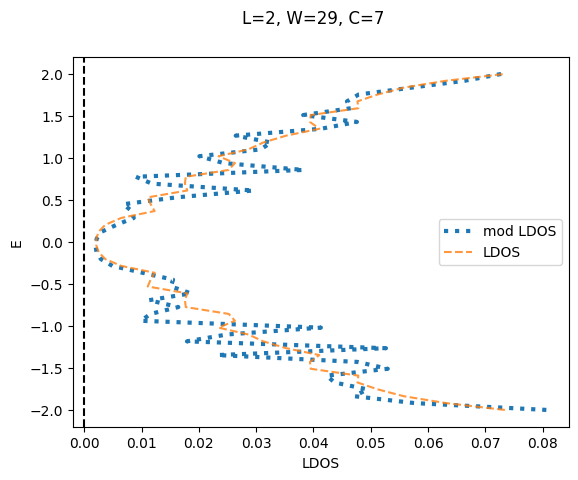

In [ ]:
!tree ../results/ -L 1

In [ ]:
def dos(lwc):
    *_, device, data = load_datastructure(lwc)
    return device, data["ldos"], data["energies"]

In [ ]:
device, ldos, energies = dos((1,9,4))
Nk, NE, Na = ldos.shape
ks, sites, norm = interactive_params(device, Nk=Nk)
x = ipywidgets.fixed(ldos)
y = ipywidgets.fixed(energies)
mod_fixed = ipywidgets.fixed(mod_ldos)
interact(plot_ldos, ldos1=x, energies=y, kidx=ks, s=sites, norm=norm, ldos2=mod_fixed)

In [ ]:
def get_bg(ldos, energies):
    Nk, NE, Ns = ldos.shape
    assert len(energies) == NE, "Arrays size for energies and korresponding LDOS must be equal"
    

In [ ]:
infer_centersize(1, 0)